# `SoftHarmonic` bond & `SoftHarmonicAngle` — emergent behaviour

These forces are **harmonic near equilibrium but saturate in the tail** (per type):

* `tail="linear"` (Huber) — harmonic up to a crossover `x_c`, then a **constant**
  restoring force/torque `k·x_c`.
* `tail="flat"` — the restoring force/torque decays smoothly to **zero** at `x_c`
  and stays zero beyond it.

The potential shapes are in [`energy_landscapes.ipynb`](energy_landscapes.ipynb).
This notebook shows three things you **cannot read off the potential** — each
measured from a real simulation and contrasted with the standard harmonic force:

1. **Kinkable filament** (flat angle) — same local stiffness, but thermal *kinks*
   appear: a non-Gaussian bending distribution and a much shorter persistence length.
2. **Breakable vs ductile bond** (flat vs linear) — a pulled chain fails *brittly*
   (flat) or *yields* ductilely (linear), while harmonic just stretches.
3. **Time-step stability** (linear bond) — the force cap removes the stiff timescale
   of taut bonds, so integration survives a much larger `dt`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import hoomd
import hoomd.md

from hoomd import align_angle

try:
    dev = hoomd.device.GPU()
except Exception:
    dev = hoomd.device.CPU()
print("HOOMD", hoomd.version.version, "| device:", type(dev).__name__,
      "| precision", hoomd.version.floating_point_precision)


def chain_positions(sim):
    # tag-ordered, UNWRAPPED positions: get_snapshot is sorted by tag; adding
    # image * box undoes periodic wrapping so bonded tangents/conformations stay
    # continuous even if the chain drifts across the box.
    s = sim.state.get_snapshot()
    box = np.asarray(s.configuration.box[:3])
    return np.asarray(s.particles.position) + np.asarray(s.particles.image) * box

HOOMD 6.1.1 | device: GPU | precision (64, 32)


## 1. Kinkable filament (flat angle)

A long stiff semiflexible chain, started from a randomly-folded worm-like walk and
run with a **harmonic** angle vs a **flat-tail** angle of the *same* stiffness `k`
(`t0 = π`). Near equilibrium the two are identical, so the local stiffness matches
(the harmonic chain recovers `Lp ≈ k`). But bending past `x_c` costs the flat tail
only `k·x_c²/6`, so **rare thermal kinks** become accessible.

In [2]:
def random_fold(N, step=1.0, turn=0.10):
    # persistent (worm-like) random walk: folded but locally near-straight
    from polykit.generators.initial_conformations import create_constrained_random_walk
    p = np.asarray(create_constrained_random_walk(N, lambda x: True, step_size=step, polar_fixed=turn))
    return p - p.mean(axis=0)


def bending(p):
    u = p[1:] - p[:-1]; u /= np.linalg.norm(u, axis=1, keepdims=True)
    return np.arccos(np.einsum("ij,ij->i", u[:-1], u[1:]).clip(-1, 1))


def kink_run(make_angle, N=500, k_bond=300.0, kT=1.0, dt=0.005,
             equil=80000, prod=80000, every=500):
    # phantom semiflexible chain; return pooled bending angles, Lp, a snapshot profile, positions
    pos = random_fold(N)
    L = 2.0 * float(np.abs(pos).max()) + 30.0
    snap = hoomd.Snapshot(dev.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [L, L, L, 0, 0, 0]
        snap.particles.N = N; snap.particles.types = ["A"]; snap.particles.mass[:] = 1.0
        snap.particles.position[:] = pos
        snap.bonds.N = N - 1; snap.bonds.types = ["A-A"]
        snap.bonds.group[:] = np.column_stack([np.arange(N - 1), np.arange(1, N)])
        snap.angles.N = N - 2; snap.angles.types = ["A-A-A"]
        snap.angles.group[:] = np.column_stack([np.arange(N - 2), np.arange(1, N - 1), np.arange(2, N)])
    sim = hoomd.Simulation(device=dev, seed=7); sim.create_state_from_snapshot(snap)
    bond = hoomd.md.bond.Harmonic(); bond.params["A-A"] = dict(k=k_bond, r0=1.0)
    lang = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=kT)
    integ = hoomd.md.Integrator(dt=dt, methods=[lang], forces=[bond, make_angle()])
    sim.operations.integrator = integ
    for wdt, wsteps in [(1e-4, 5000), (1e-3, 5000), (dt, 10000)]:   # relax the sharp initial folds
        integ.dt = wdt; sim.run(wsteps)
    integ.dt = dt; sim.run(equil)
    betas = []
    for _ in range(prod // every):
        sim.run(every); betas.append(bending(chain_positions(sim)))
    p_last = chain_positions(sim)
    Lp = -1.0 / np.log(np.cos(np.concatenate(betas)).mean())        # bond length b = 1
    return np.concatenate(betas), Lp, bending(p_last), p_last


def angle(cls, **params):
    f = cls(); f.params["A-A-A"] = params; return f


K, XC = 180.0, 0.5
bh, Lph, profh, posh = kink_run(lambda: angle(hoomd.md.angle.Harmonic, k=K, t0=np.pi))
bf, Lpf, proff, posf = kink_run(lambda: angle(align_angle.SoftHarmonicAngle, k=K, t0=np.pi, x_c=XC, tail="flat"))
print(f"plateau energy k*x_c^2/6 = {K*XC**2/6:.1f} kT  (bends past x_c cost <= this)")
print(f"harmonic: Lp = {Lph:6.1f} b,  kinks (beta>x_c) = {np.mean(bh>XC):.2%}")
print(f"flat:     Lp = {Lpf:6.1f} b,  kinks (beta>x_c) = {np.mean(bf>XC):.2%}")

plateau energy k*x_c^2/6 = 7.5 kT  (bends past x_c cost <= this)
harmonic: Lp =  179.7 b,  kinks (beta>x_c) = 0.00%
flat:     Lp =   27.3 b,  kinks (beta>x_c) = 3.84%


# ═══════ EXECUTION COMPLETE — VISUALIZATION & ANALYSIS BELOW ═══════

### The chains

Same local stiffness, but the flat tail permits sharp kinks. A 2-D projection onto
each chain's principal axes; joints bent past `x_c` are marked in red.

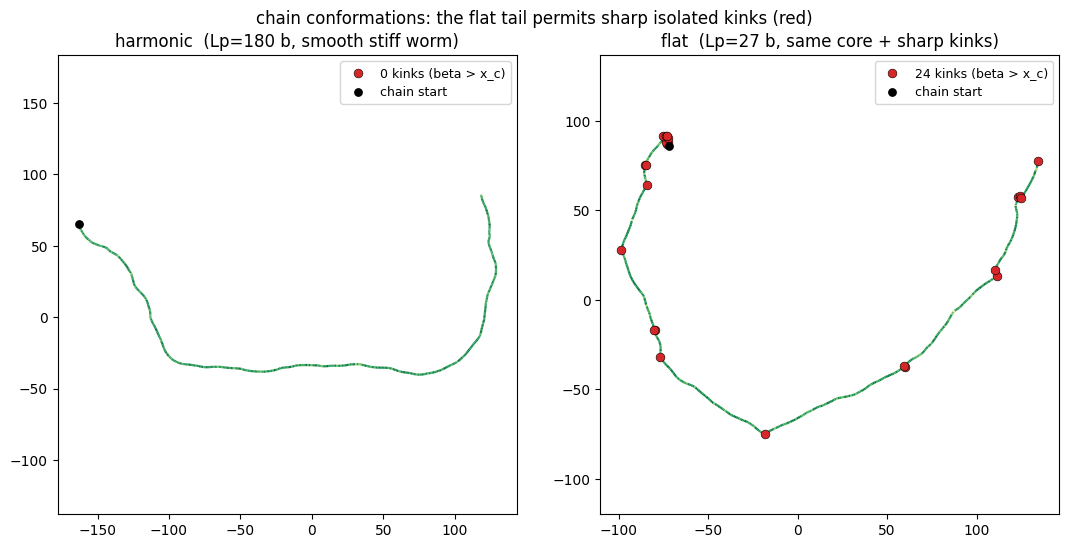

In [3]:
def project2d(p):
    c = p - p.mean(axis=0)
    _, _, Vt = np.linalg.svd(c, full_matrices=False)
    return c @ Vt[:2].T


def draw_chain(ax, p, prof, title):
    q = project2d(p)
    # colour the backbone by local bending so the kinks light up along the chain
    seg = np.stack([q[:-1], q[1:]], axis=1)
    from matplotlib.collections import LineCollection
    lc = LineCollection(seg, cmap="RdYlGn_r", norm=plt.Normalize(0, 1.0), lw=1.6)
    lc.set_array(np.concatenate([[0], prof]))
    ax.add_collection(lc)
    kb = np.where(prof > XC)[0] + 1
    ax.scatter(q[kb, 0], q[kb, 1], c="C3", s=40, edgecolors="k", linewidths=0.4,
               zorder=6, label=f"{len(kb)} kinks (beta > x_c)")
    ax.scatter(*q[0], c="k", s=28, zorder=7, label="chain start")
    ctr = 0.5 * (q.max(0) + q.min(0)); rad = 0.55 * float(np.ptp(q, axis=0).max())
    ax.set_xlim(ctr[0] - rad, ctr[0] + rad); ax.set_ylim(ctr[1] - rad, ctr[1] + rad)
    ax.set_aspect("equal"); ax.set_title(title); ax.legend(loc="upper right", fontsize=9)


fig, ax = plt.subplots(1, 2, figsize=(11, 5.4))
draw_chain(ax[0], posh, profh, f"harmonic  (Lp={Lph:.0f} b, smooth stiff worm)")
draw_chain(ax[1], posf, proff, f"flat  (Lp={Lpf:.0f} b, same core + sharp kinks)")
fig.suptitle("chain conformations: the flat tail permits sharp isolated kinks (red)")
fig.tight_layout(); plt.show()

The bending-angle statistics behind the pictures:

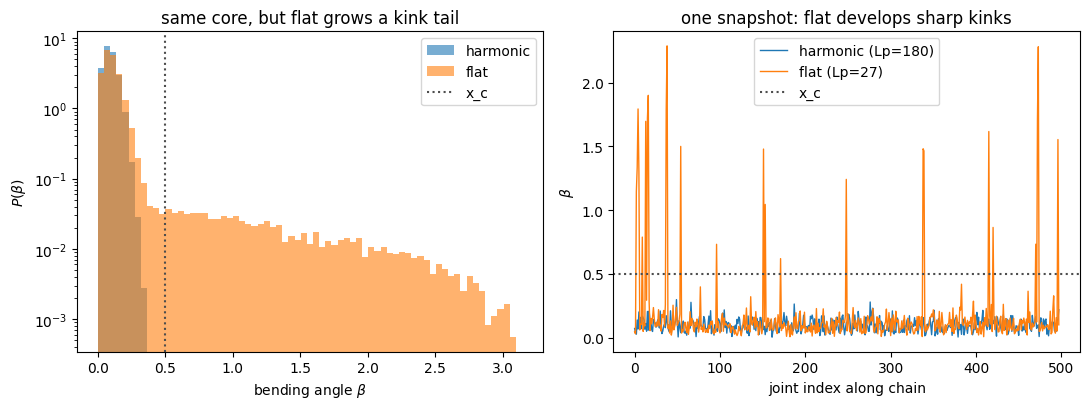

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
bins = np.linspace(0, np.pi, 70)
a1.hist(bh, bins=bins, density=True, alpha=0.6, label="harmonic")
a1.hist(bf, bins=bins, density=True, alpha=0.6, label="flat")
a1.axvline(XC, color="0.3", ls=":", label="x_c")
a1.set_yscale("log"); a1.set_xlabel(r"bending angle $\beta$"); a1.set_ylabel(r"$P(\beta)$")
a1.set_title("same core, but flat grows a kink tail"); a1.legend()
a2.plot(np.arange(len(profh)), profh, lw=1.0, label=f"harmonic (Lp={Lph:.0f})")
a2.plot(np.arange(len(proff)), proff, lw=1.0, label=f"flat (Lp={Lpf:.0f})")
a2.axhline(XC, color="0.3", ls=":", label="x_c")
a2.set_xlabel("joint index along chain"); a2.set_ylabel(r"$\beta$")
a2.set_title("one snapshot: flat develops sharp kinks"); a2.legend()
fig.tight_layout(); plt.show()

## 2. Breakable vs ductile bond (flat vs linear)

Pull a chain by its ends under **displacement control** — fix both ends at a
separation `d`, ramp it, and measure the tension the chain sustains. Unlike a
force-controlled pull, this captures what happens *after* the peak:

* **harmonic** — tension rises without bound (elastic).
* **linear** — rises, then plateaus at the yield `k·x_c` and flows (ductile).
* **flat** — rises to a peak, then **collapses to zero**: the strain localizes into
  one bond that stretches past `x_c` and ruptures (brittle). The chain fails below a
  single bond's ideal `F* ≈ 0.286·k·x_c` because the weakest bond goes first.

linear plateau ~ k*x_c = 20;  flat peaks at 3.3 then ruptures to 0


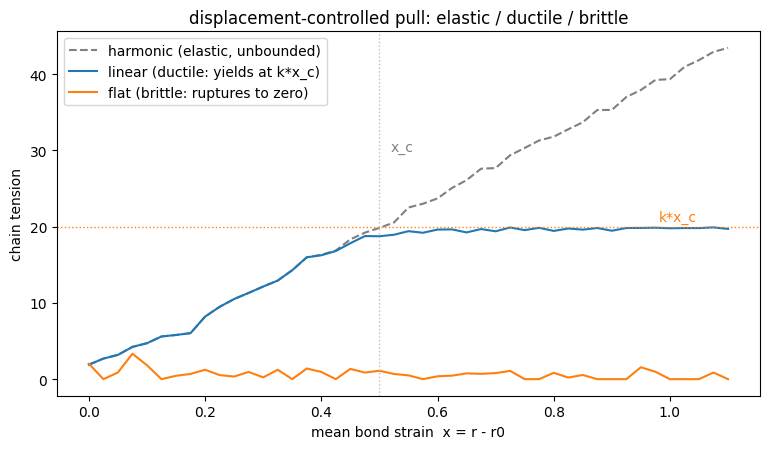

In [5]:
def bond(cls, **params):
    f = cls(); f.params["A-A"] = params; return f


def tension_curve(make_bond, x_mean, N=20, r0=1.0, kT=0.1, equil=3000, nsamp=25, sample_every=100):
    # chain along x, both ends (0, N-1) fixed; ramp the end separation (displacement
    # control) and measure the tension the chain holds (force on the anchor bond)
    L = 1.0e5
    snap = hoomd.Snapshot(dev.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [L, L, L, 0, 0, 0]
        snap.particles.N = N; snap.particles.types = ["A"]; snap.particles.mass[:] = 1.0
        snap.particles.position[:] = np.column_stack([np.arange(N) * r0, np.zeros(N), np.zeros(N)])
        snap.bonds.N = N - 1; snap.bonds.types = ["A-A"]
        snap.bonds.group[:] = np.column_stack([np.arange(N - 1), np.arange(1, N)])
    sim = hoomd.Simulation(device=dev, seed=3); sim.create_state_from_snapshot(snap)
    b = make_bond()
    mobile = hoomd.filter.SetDifference(hoomd.filter.All(), hoomd.filter.Tags([0, N - 1]))
    lang = hoomd.md.methods.Langevin(filter=mobile, kT=kT)
    sim.operations.integrator = hoomd.md.Integrator(dt=0.005, methods=[lang], forces=[b])
    sim.run(0)
    T = []
    for x in x_mean:
        d = (N - 1) * (r0 + x)                          # imposed end-to-end distance
        s = sim.state.get_snapshot()
        s.particles.position[:, 0] = np.linspace(0, d, N)
        s.particles.position[:, 1] = 0.0; s.particles.position[:, 2] = 0.0
        sim.state.set_snapshot(s)
        sim.run(equil)
        ff = []
        for _ in range(nsamp):
            sim.run(sample_every)
            ff.append(abs(float(np.asarray(b.forces)[0, 0])))   # tension on the anchor
        T.append(np.mean(ff))
    return np.array(T)


K, XC = 40.0, 0.5
x = np.linspace(0.0, 1.1, 45)
Th = tension_curve(lambda: bond(hoomd.md.bond.Harmonic, k=K, r0=1.0), x)
Tl = tension_curve(lambda: bond(align_angle.SoftHarmonic, k=K, r0=1.0, x_c=XC, tail="linear"), x)
Tf = tension_curve(lambda: bond(align_angle.SoftHarmonic, k=K, r0=1.0, x_c=XC, tail="flat"), x)
print(f"linear plateau ~ k*x_c = {K*XC:.0f};  flat peaks at {Tf.max():.1f} then ruptures to 0")

fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.plot(x, Th, "--", color="0.5", label="harmonic (elastic, unbounded)")
ax.plot(x, Tl, label="linear (ductile: yields at k*x_c)")
ax.plot(x, Tf, label="flat (brittle: ruptures to zero)")
ax.axhline(K * XC, color="C1", ls=":", lw=1); ax.text(0.98, K * XC + 0.8, "k*x_c", color="C1")
ax.axvline(XC, color="0.75", ls=":", lw=1); ax.text(XC + 0.02, 30, "x_c", color="0.5")
ax.set_xlabel("mean bond strain  x = r - r0"); ax.set_ylabel("chain tension")
ax.set_title("displacement-controlled pull: elastic / ductile / brittle"); ax.legend()
fig.tight_layout(); plt.show()

## 3. Time-step stability (linear bond)

A plain harmonic bond is linear, so its integration is stable only for `dt < ~2/√k`
however far it is stretched. The **linear** tail is *flat* beyond `x_c` (zero
curvature), so bonds held in the tail impose **no** stiff timescale. We hold a chain
taut (both ends fixed at 60% strain, every bond in the tail) and sweep `dt`.

max stable dt:  harmonic = 0.06,  SoftHarmonic linear = 0.18   (3x)


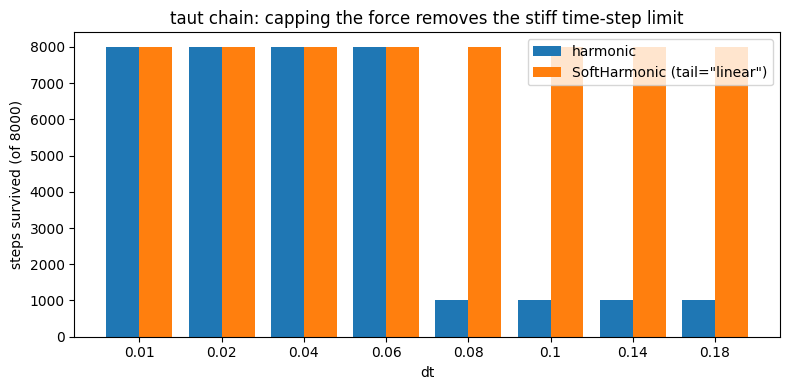

In [6]:
def stable_to(make_bond, dt, N=40, strain=0.6, kT=1.0, n_steps=8000, chunk=1000):
    # held-taut chain (ends fixed); steps survived before blow-up (or n_steps)
    try:
        L = 400.0; d = (N - 1) * (1 + strain)
        snap = hoomd.Snapshot(dev.communicator)
        if snap.communicator.rank == 0:
            snap.configuration.box = [L, L, L, 0, 0, 0]
            snap.particles.N = N; snap.particles.types = ["A"]; snap.particles.mass[:] = 1.0
            p = np.zeros((N, 3)); p[:, 0] = np.linspace(-d / 2, d / 2, N)
            snap.particles.position[:] = p
            snap.bonds.N = N - 1; snap.bonds.types = ["A-A"]
            snap.bonds.group[:] = np.column_stack([np.arange(N - 1), np.arange(1, N)])
        sim = hoomd.Simulation(device=dev, seed=123); sim.create_state_from_snapshot(snap)
        mobile = hoomd.filter.SetDifference(hoomd.filter.All(), hoomd.filter.Tags([0, N - 1]))
        lang = hoomd.md.methods.Langevin(filter=mobile, kT=kT)
        sim.operations.integrator = hoomd.md.Integrator(dt=dt, methods=[lang], forces=[make_bond()])
        thermo = hoomd.md.compute.ThermodynamicQuantities(filter=mobile)
        sim.operations.computes.append(thermo)
        done = 0
        for _ in range(n_steps // chunk):
            sim.run(chunk); done += chunk
            fin = np.all(np.isfinite(chain_positions(sim)))
            if not (np.isfinite(thermo.kinetic_energy) and thermo.kinetic_energy / N < 1e6 and fin):
                return done
        return n_steps
    except Exception:
        return 0


K, XC = 200.0, 0.3
dts = [0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.14, 0.18]
sh = [stable_to(lambda: bond(hoomd.md.bond.Harmonic, k=K, r0=1.0), dt) for dt in dts]
sl = [stable_to(lambda: bond(align_angle.SoftHarmonic, k=K, r0=1.0, x_c=XC, tail="linear"), dt) for dt in dts]
maxh = max([dt for dt, s in zip(dts, sh) if s == 8000], default=0)
maxl = max([dt for dt, s in zip(dts, sl) if s == 8000], default=0)
print(f"max stable dt:  harmonic = {maxh},  SoftHarmonic linear = {maxl}"
      + (f"   ({maxl/maxh:.0f}x)" if maxh else ""))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(dts)); w = 0.4
ax.bar(x - w/2, sh, w, label="harmonic")
ax.bar(x + w/2, sl, w, label='SoftHarmonic (tail="linear")')
ax.set_xticks(x); ax.set_xticklabels([str(d) for d in dts])
ax.set_xlabel("dt"); ax.set_ylabel("steps survived (of 8000)")
ax.set_title("taut chain: capping the force removes the stiff time-step limit"); ax.legend()
fig.tight_layout(); plt.show()

**Takeaways**

* **Flat angle → kinks.** Identical local stiffness, yet letting bends past `x_c`
  saturate turns a near-rigid rod into a kinked coil — a heavy-tailed `P(β)` and a
  much shorter persistence length (relevant to chromatin/DNA kinking).
* **Flat vs linear bond → brittle vs ductile.** The flat tail gives a finite rupture
  force (breakable/sacrificial bonds); the linear tail yields at constant force
  without breaking (a tough, capped bond).
* **Linear tail → stability.** Capping the force removes the stiff timescale of taut
  bonds, allowing several-fold larger time steps than a plain harmonic bond.